# Visualization

In [1]:
from Config.config import CONFIG
CONFIG = CONFIG("LinkPred")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

shap_event_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/Shapley4TGNNEvent.csv")
shap_feature_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/Shapley4TGNNFeature.csv")
tgnn_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/TGNNExplainer.csv")
tempme_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/TempME.csv")

shap_event_df['Explainer'] = 'Shapley4TGNNEvent'
shap_feature_df['Explainer'] = 'Shapley4TGNNFeature'
tgnn_df['Explainer'] = 'TGNNExplainer'
tempme_df['Explainer'] = 'TempME'

results_df = pd.concat([shap_event_df, shap_feature_df, tgnn_df, tempme_df], axis=0)
results_df.head()

,Original prediction,Ground truth,y,Sparsity thresholds,Fidelity to prediction,Fidelity to prediction (logit),Deviation to ground truth,Accuracy,Source,Destination,Timestamp,Instance index,Remove technique,Explainer
0,0.867765,1.0,0.917191,0.000000,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
1,0.867765,1.0,0.917191,0.000911,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
2,0.867765,1.0,0.917191,0.001212,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
3,0.867765,1.0,0.917191,0.001612,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
4,0.867765,1.0,0.917191,0.002144,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent


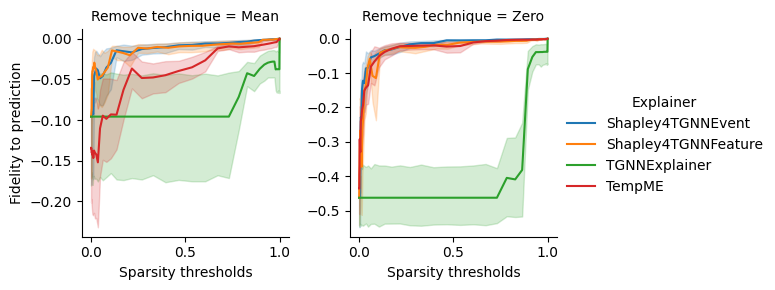

In [3]:
df = results_df.copy()

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", sharey=False, sharex=False)
g.map(sns.lineplot, 'Sparsity thresholds', 'Fidelity to prediction')
#Add legend
g.add_legend()

In [4]:
from sklearn.metrics import auc
from scipy.integrate import trapezoid

# Change these two names when a different curve should be integrated.
x_column = "Sparsity thresholds"
y_column = "Fidelity to prediction"

group_columns = ["Remove technique", "Explainer", "Instance index"]

result = []
for identifiers, group in results_df.groupby(group_columns, dropna=False):
    area = trapezoid(group[y_column], group[x_column])
    technique, explainer, instance = identifiers
    result.append({
        "Explainer": explainer,
        "technique": technique,
        "instance": instance,
        "AUC": area,
    })

auc_df = pd.DataFrame(result, columns=["Explainer", "technique", "instance", "AUC"])
auc_df

,Explainer,technique,instance,AUC
0,Shapley4TGNNEvent,Mean,0,-0.003854
1,Shapley4TGNNEvent,Mean,1,-0.052025
2,Shapley4TGNNEvent,Mean,2,-0.003490
3,Shapley4TGNNEvent,Mean,3,-0.009496
4,Shapley4TGNNEvent,Mean,4,-0.005596
...,...,...,...,...
107,TempME,Zero,10,-0.059182
108,TempME,Zero,11,-0.040667
109,TempME,Zero,12,-0.061904
110,TempME,Zero,13,-0.020594


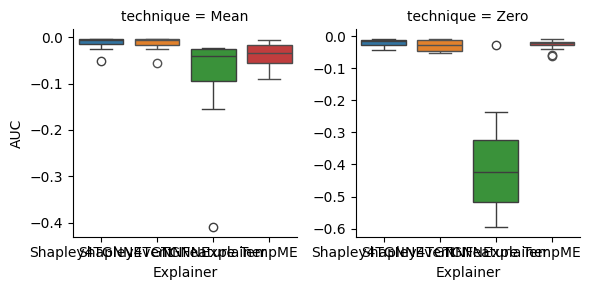

In [5]:
g = sns.FacetGrid(auc_df, col="technique", hue="Explainer", sharey=False, sharex=False)
g.map(sns.boxplot, "Explainer", "AUC", order=["Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer", "TempME"])

In [9]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

shap_event_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNEvent") & (auc_df["technique"] == "Zero")]["AUC"].values
shap_feature_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNFeature") & (auc_df["technique"] == "Zero")]["AUC"].values
tgnn_auc = auc_df[(auc_df["Explainer"] == "TGNNExplainer") & (auc_df["technique"] == "Zero")]["AUC"].values
tempme_auc = auc_df[(auc_df["Explainer"] == "TempME") & (auc_df["technique"] == "Zero")]["AUC"].values

statistic1, p_value1 = wilcoxon(shap_event_auc, tempme_auc, alternative="greater")
statistic2, p_value2 = wilcoxon(shap_event_auc, tgnn_auc, alternative="greater")

corrected = multipletests([p_value1, p_value2], method='holm')[1]

print(statistic1, p_value1)
print(statistic2, p_value2)

print(corrected)

70.0 0.14788818359375
104.0 0.0001220703125
[0.14788818 0.00024414]
